# Analýza hlavních komponent

## Úkol

- V datasetu Portland Housing Prices/Sales Jul 2020 - Jul 2021 zjistěte, jestli je zde problém multikolinearity.
- Proveďte analyzu hlavních komponent
- Vytvořte lineární model z PCA a model porovnejte s minulým cvičením

# Načtení dat

In [6]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv ("../dataset/portland_filtered.csv",  sep=';')

# Analýza
- zobrazte data
- vyřešte NaN hodnoty
- zobrazte základní statistiky dat
- zobrazte korelační matici

In [3]:
# - zobrazte data
data.head()

,bathrooms,bedrooms,livingArea,age,price
0,3,5,3470,7,1165000
1,4,5,3374,85,1050000
2,3,3,3265,20,442500
3,3,3,3192,36,765000
4,3,4,3157,73,815000


In [4]:
# - vyřešte NaN hodnoty
data=data.dropna()

In [5]:
# - zobrazte základní statistiky dat
data.describe()

,bathrooms,bedrooms,livingArea,age,price
count,100.000000,100.000000,100.000000,100.00000,1.000000e+02
mean,2.380000,3.260000,1974.080000,49.88000,5.196074e+05
std,0.838228,0.860115,663.629851,32.77973,1.722241e+05
min,1.000000,1.000000,766.000000,3.00000,1.650000e+05
25%,2.000000,3.000000,1530.000000,20.00000,4.125000e+05
50%,2.000000,3.000000,1859.000000,47.50000,5.000000e+05
75%,3.000000,4.000000,2490.250000,75.25000,5.995312e+05
max,5.000000,6.000000,3470.000000,114.00000,1.165000e+06


In [8]:
# - zobrazte korelační matici
corr_matrix = data.corr()

print(corr_matrix)

            bathrooms  bedrooms  livingArea       age     price
bathrooms    1.000000  0.618132    0.566558 -0.536517  0.463856
bedrooms     0.618132  1.000000    0.641684 -0.224947  0.498934
livingArea   0.566558  0.641684    1.000000  0.019381  0.759973
age         -0.536517 -0.224947    0.019381  1.000000  0.114328
price        0.463856  0.498934    0.759973  0.114328  1.000000


# Příprava dat
- vyberte X promenné bathrooms', 'bedrooms', 'livingArea','age','price'
- proměnné standardizujte

In [9]:
# - vyberte X promenné bathrooms', 'bedrooms', 'livingArea','age','price'
X = data[['bathrooms', 'bedrooms', 'livingArea', 'age', 'price']]

In [ ]:
# - proměnné standardizujte
def rescale(X):
    mean = X.mean()
    std = X.std()
    scaled_X = [(i - mean)/std for i in X]
    return pd.Series(scaled_X)

data_std = pd.DataFrame(columns=data.columns)
for i in data.columns:
    data_std[i] = rescale(data[i])


# Zobrazte VIF pro každou proměnnou

In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

     Variable        VIF
0   bathrooms  21.919138
1    bedrooms  25.671056
2  livingArea  31.512489
3         age   4.076016
4       price  25.954004


# PCA
- Proveďte PCA
- zobrazte korelační matici

In [ ]:
# - Proveďte PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=4)
X = data_std.drop('price', axis=1)
X_pca = pca.fit_transform(X)
data_std_pca = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2', 'PCA3', 'PCA4'])
data_std_pca['price'] = data_std['price']


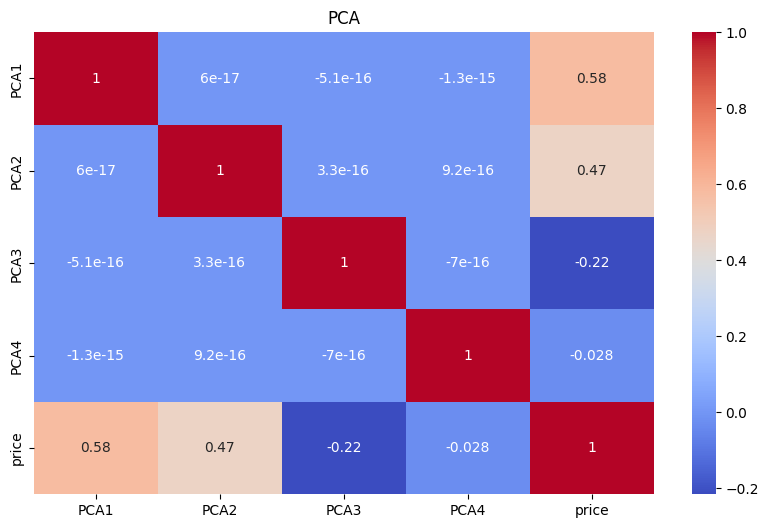

In [33]:
# - zobrazte korelační matici
fig = plt.figure(figsize=(10,6))
sns.heatmap(data_std_pca.corr(), annot=True, cmap='coolwarm')
plt.title("PCA")
plt.show()

# Lineární model
- Vytvořte a natrénujte Lineární model pro PCA proměnné
- Zobrazte R2 a RMSE

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [ ]:
# - Vytvořte a natrénujte Lineární model pro PCA proměnné
X = data_std_pca.drop('price', axis=1) 
y = data_std_pca['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [ ]:
# - Zobrazte R2 a RMSE
r2 = r2_score(y_test, y_pred) 
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  

print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R²: 0.4425
RMSE: 0.8611
